# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Manuel Elias Orellana Lavayen

**Fecha:** 25/6/2026

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [32]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [33]:
# TODO: Cargar el dataset car.data
#
# Instrucciones:
# 1. Defina los nombres de columnas en una lista:
#    col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
# 2. Use pd.read_csv() para cargar 'car.data' con header=None y names=col_names
# 3. Imprima las dimensiones del dataset con df.shape
# 4. Muestre las primeras 5 filas con df.head()

col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header=None , names=col_names)
print(df.shape)
df.head()

(1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** B

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [34]:
# TODO: Explorar información del dataset
#
# Instrucciones:
# 1. Use df.info() para ver tipos de datos y valores no nulos
# 2. Use df.describe() para estadísticas descriptivas

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [36]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [37]:
# TODO: Verificar valores únicos por columna
#
# Instrucciones:
# 1. Use un loop for para recorrer df.columns
# 2. Para cada columna, imprima df[col].unique()

for col in df.columns:
    print(df[col].unique())

['vhigh' 'high' 'med' 'low']
['vhigh' 'high' 'med' 'low']
['2' '3' '4' '5more']
['2' '4' 'more']
['small' 'med' 'big']
['low' 'med' 'high']
['unacc' 'acc' 'vgood' 'good']


In [38]:
# TODO: Verificar valores nulos
#
# Instrucciones:
# 1. Use df.isnull().sum() para contar valores nulos por columna
df.isnull().sum()


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Text(0.5, 1.0, 'Proporción de la clasificación de los vehículos')

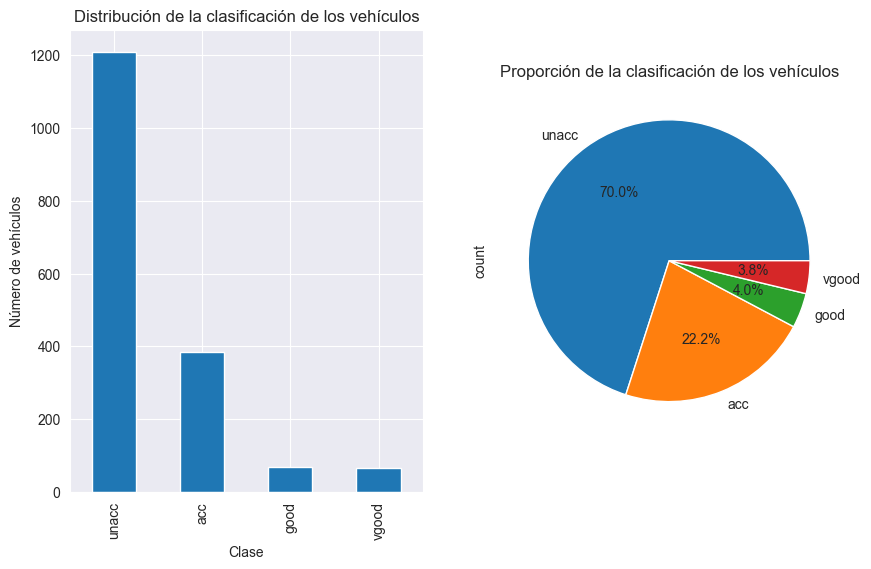

In [39]:
# TODO: Visualizar la distribución de la variable objetivo
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use df['class'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas apropiadas
# 5. Imprima el conteo de clases con df['class'].value_counts()

figure, axis = plt.subplots(nrows=1, ncols=2)

df['class'].value_counts().plot(kind='bar', ax= axis[0])
axis[0].set_title("Distribución de la clasificación de los vehículos")
axis[0].set_xlabel("Clase")
axis[0].set_ylabel("Número de vehículos")

df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax= axis[1])
axis[1].set_title("Proporción de la clasificación de los vehículos")

### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

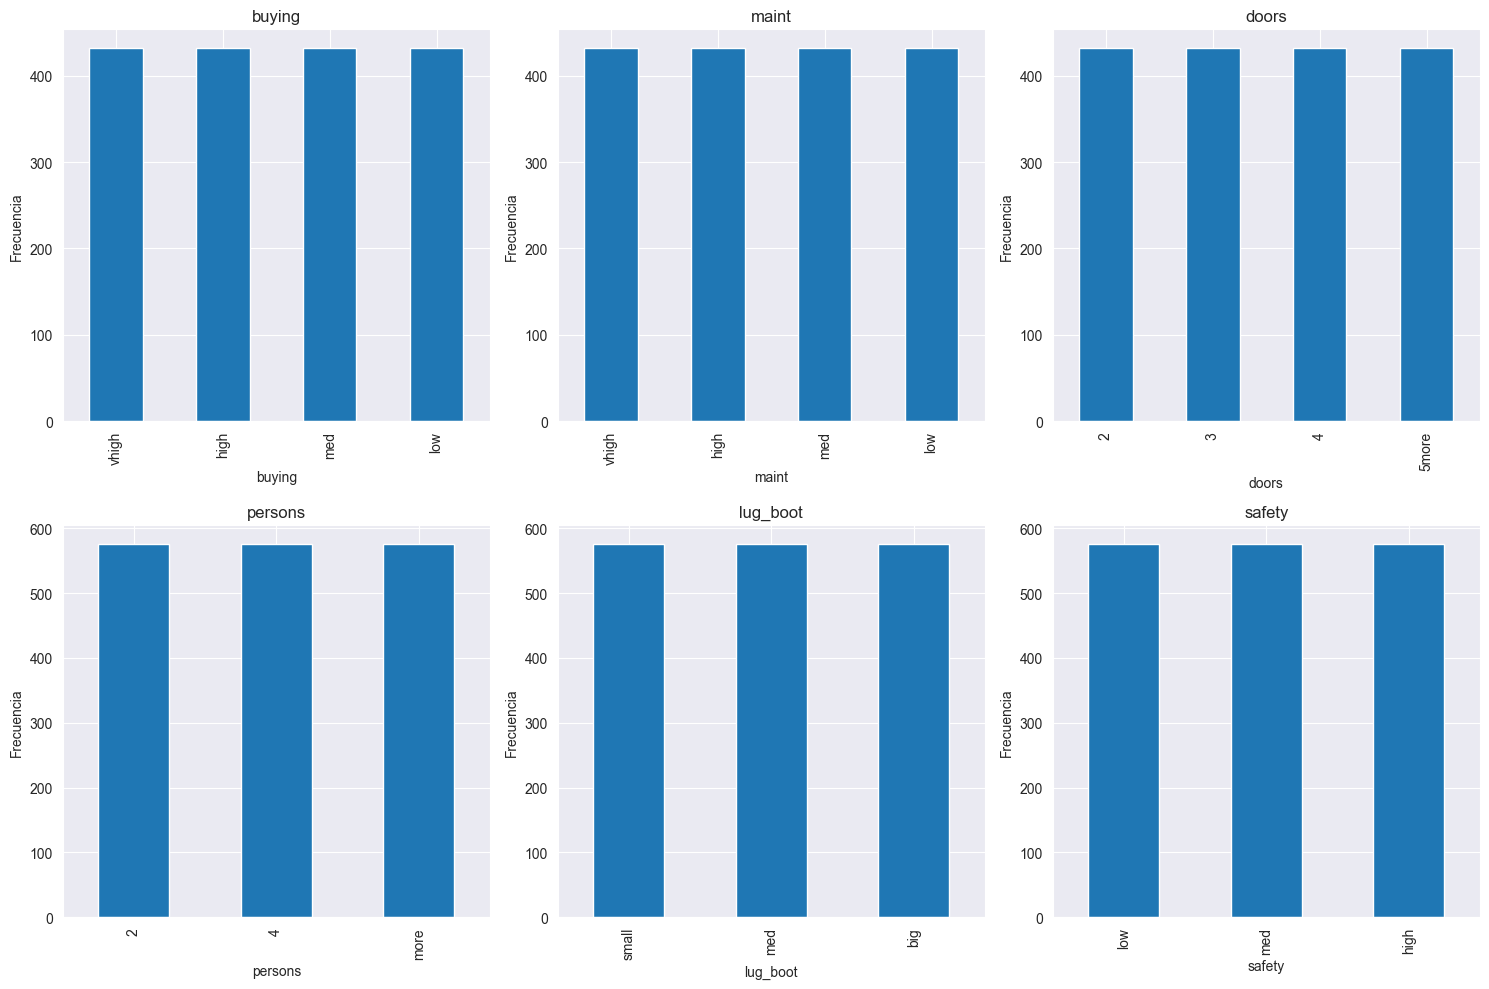

In [40]:
# TODO: Visualizar distribución de características
#
# Instrucciones:
# 1. Cree una figura con subplots 2x3 usando plt.subplots(2, 3, figsize=(15, 10))
# 2. Defina features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
# 3. Use un loop para graficar df[feature].value_counts().plot(kind='bar') en cada subplot
# 4. Agregue títulos a cada subplot

features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
figue, axis = plt.subplots(2, 3, figsize=(15, 10))
axis = axis.flatten() # Aplanando arreglo
for ax, feature in enumerate(features):
    df[feature].value_counts().plot(kind='bar', ax= axis[ax])
    axis[ax].set_title(feature)
    axis[ax].set_xlabel(feature)
    axis[ax].set_ylabel('Frecuencia')
plt.tight_layout()

### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [41]:
# TODO: Aplicar Label Encoding a todas las columnas
#
# Instrucciones:
# 1. Cree una copia del DataFrame: df_encoded = df.copy()
# 2. Cree un diccionario vacío: label_encoders = {}
# 3. Para cada columna en df_encoded.columns:
#    a. Cree un LabelEncoder: le = LabelEncoder()
#    b. Transforme la columna: df_encoded[col] = le.fit_transform(df_encoded[col])
#    c. Guarde el encoder: label_encoders[col] = le
# 4. Muestre las primeras filas del DataFrame codificado

df_encoded = df.copy()
label_encoders = {}
for columna in df_encoded.columns:
    codificador = LabelEncoder()
    df_encoded[columna] = codificador.fit_transform(df_encoded[columna])
    label_encoders[columna] = codificador


df_encoded.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [42]:
# TODO: Mostrar el mapeo de etiquetas
#
# Instrucciones:
# 1. Para cada columna y encoder en label_encoders.items():
#    - Imprima el mapeo usando dict(zip(le.classes_, range(len(le.classes_))))

for columna, le in label_encoders.items():
    print(f"{columna}:")
    print(dict(zip(le.classes_, range(len(le.classes_)))))
    print()

buying:
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

maint:
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

doors:
{'2': 0, '3': 1, '4': 2, '5more': 3}

persons:
{'2': 0, '4': 1, 'more': 2}

lug_boot:
{'big': 0, 'med': 1, 'small': 2}

safety:
{'high': 0, 'low': 1, 'med': 2}

class:
{'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}



### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B

## Parte 4: División de Datos

In [43]:
# TODO: Separar características (X) y variable objetivo (y)
#
# Instrucciones:
# 1. X = df_encoded.drop('class', axis=1) para obtener solo las características
# 2. y = df_encoded['class'] para obtener la variable objetivo
# 3. Imprima las formas de X y y
# 4. Imprima los nombres de las características con list(X.columns)

X = df_encoded.drop('class', axis=1)
y = df_encoded['class']
print(f"Dimension X: {X.shape}")
print(f"Dimension y: {y.shape}")
print(f"Nombres de las características de X{X.columns}")

Dimension X: (1728, 6)
Dimension y: (1728,)
Nombres de las características de XIndex(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'], dtype='object')


In [44]:
# TODO: Dividir en conjuntos de entrenamiento y prueba
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.33, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (1157, 6)
X_test: (571, 6)
y_train: (1157,)
y_test: (571,)


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [45]:
# TODO: Crear y entrenar el modelo con criterio Gini
#
# Instrucciones:
# 1. Cree el clasificador: clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
# 2. Entrene con clf_gini.fit(X_train, y_train)
# 3. Imprima la profundidad del árbol con clf_gini.get_depth()
# 4. Imprima el número de hojas con clf_gini.get_n_leaves

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)
print(f"Profundidad del árbol: {clf_gini.get_depth()}")
print(f"Numero de hojas: {clf_gini.get_n_leaves()}")

Profundidad del árbol: 3
Numero de hojas: 5


In [46]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con y_pred_gini = clf_gini.predict(X_test)
# 2. Calcule la exactitud en test con accuracy_score(y_test, y_pred_gini)
# 3. Prediga en train y calcule la exactitud en entrenamiento
# 4. Imprima ambas exactitudes

y_pred_test_gini = clf_gini.predict(X_test)
y_pred_train_gini = clf_gini.predict(X_train)

exactitud_test_gini = accuracy_score(y_test, y_pred_test_gini)
exactitud_train_gini = accuracy_score(y_train, y_pred_train_gini)

print(f"Exactitud con datos de testeo: {exactitud_test_gini}")
print(f"Exactitud con datos de entrenamiento: {exactitud_train_gini}")


Exactitud con datos de testeo: 0.7653239929947461
Exactitud con datos de entrenamiento: 0.7744165946413137


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3? (En si deberia ser exactitud, ya que si hablamos "del modelo", las presciciones se calculan por clase)

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [47]:
# TODO: Crear y entrenar el modelo con criterio Entropy
#
# Instrucciones:
# 1. Cree el clasificador: clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# 2. Entrene con clf_entropy.fit(X_train, y_train)
# 3. Imprima la profundidad y número de hojas

clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_entropy.fit(X_train, y_train)

print(f"Profundidad del árbol: {clf_entropy.get_depth()}")
print(f"Numero de hojas: {clf_entropy.get_n_leaves()}")

Profundidad del árbol: 3
Numero de hojas: 5


In [48]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con clf_entropy.predict(X_test)
# 2. Calcule y muestre la precisión en test y train
y_pred_test_entropy = clf_entropy.predict(X_test)
y_pred_train_entropy = clf_entropy.predict(X_train)

exactitud_test_entropy = accuracy_score(y_test, y_pred_test_entropy)
exactitud_train_entropy = accuracy_score(y_train, y_pred_train_entropy)

print(f"Exactitud con datos de testeo: {exactitud_test_entropy}")
print(f"Exactitud con datos de entrenamiento: {exactitud_train_entropy}")

Exactitud con datos de testeo: 0.7653239929947461
Exactitud con datos de entrenamiento: 0.7744165946413137


In [49]:
print(exactitud_test_gini > exactitud_test_entropy)
print(exactitud_test_gini == exactitud_test_entropy)
print(exactitud_test_gini < exactitud_test_entropy)
print()
print(exactitud_train_gini > exactitud_train_entropy)
print(exactitud_train_gini == exactitud_train_entropy)
print(exactitud_train_gini < exactitud_train_entropy)

False
True
False

False
True
False


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [50]:
# TODO: Crear tabla comparativa
#
# Instrucciones:
# 1. Cree un DataFrame con las siguientes columnas:
#    - 'Criterio': ['Gini Index', 'Entropy']
#    - 'Precisión Train': precisiones de entrenamiento
#    - 'Precisión Test': precisiones de prueba
#    - 'Profundidad': profundidad de cada árbol
#    - 'Hojas': número de hojas de cada árbol
# 2. Imprima la tabla

tabla_comparativa_dic = {
    'Gini Index': [exactitud_train_gini, exactitud_test_gini],
    'Entropy': [exactitud_train_entropy, exactitud_test_entropy],
}
df_tabla_comparativa = pd.DataFrame(data= tabla_comparativa_dic, index= ["Exactitud train", "Exactitud test"] )
df_tabla_comparativa


,Gini Index,Entropy
Exactitud train,0.774417,0.774417
Exactitud test,0.765324,0.765324


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B

## Parte 8: Matriz de Confusión y Métricas

<Axes: >

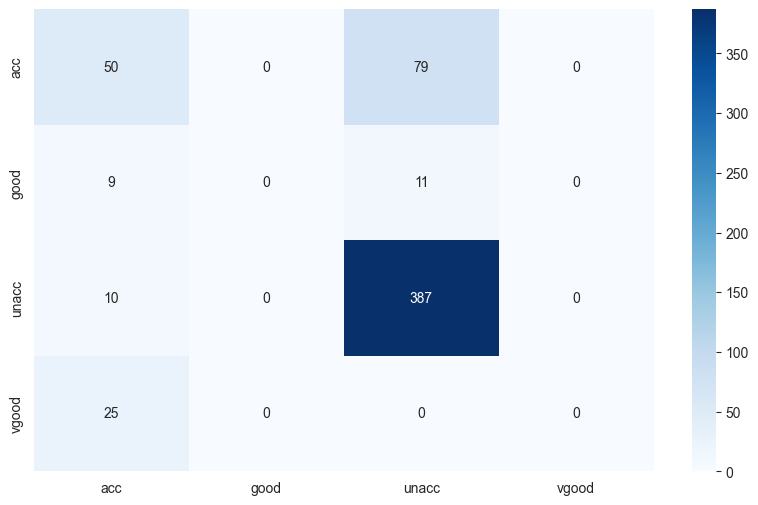

In [51]:
# TODO: Calcular y visualizar la matriz de confusión para el modelo Gini
#
# Instrucciones:
# 1. Calcule la matriz con confusion_matrix(y_test, y_pred_gini)
# 2. Obtenga los nombres de clase con label_encoders['class'].classes_
# 3. Use sns.heatmap() para visualizar con annot=True, fmt='d', cmap='Blues'
# 4. Configure xticklabels y yticklabels con los nombres de clase
# 5. Agregue título y etiquetas de ejes

matriz_confusion = confusion_matrix(y_test, y_pred_test_gini)
nombres_clases = label_encoders['class'].classes_
sns.heatmap(data=matriz_confusion, xticklabels=nombres_clases, yticklabels=nombres_clases, annot=True, fmt='d', cmap='Blues')


In [52]:
# TODO: Imprimir el reporte de clasificación
#
# Instrucciones:
# 1. Use classification_report(y_test, y_pred_gini, target_names=class_names)
# 2. Imprima el reporte

reporte_clasificacion = classification_report(y_test, y_pred_test_gini, target_names= nombres_clases)
print(reporte_clasificacion)

              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

## Parte 9: Visualización del Árbol de Decisión

Text(0.5, 1.0, 'Árbol de clasificación gini')

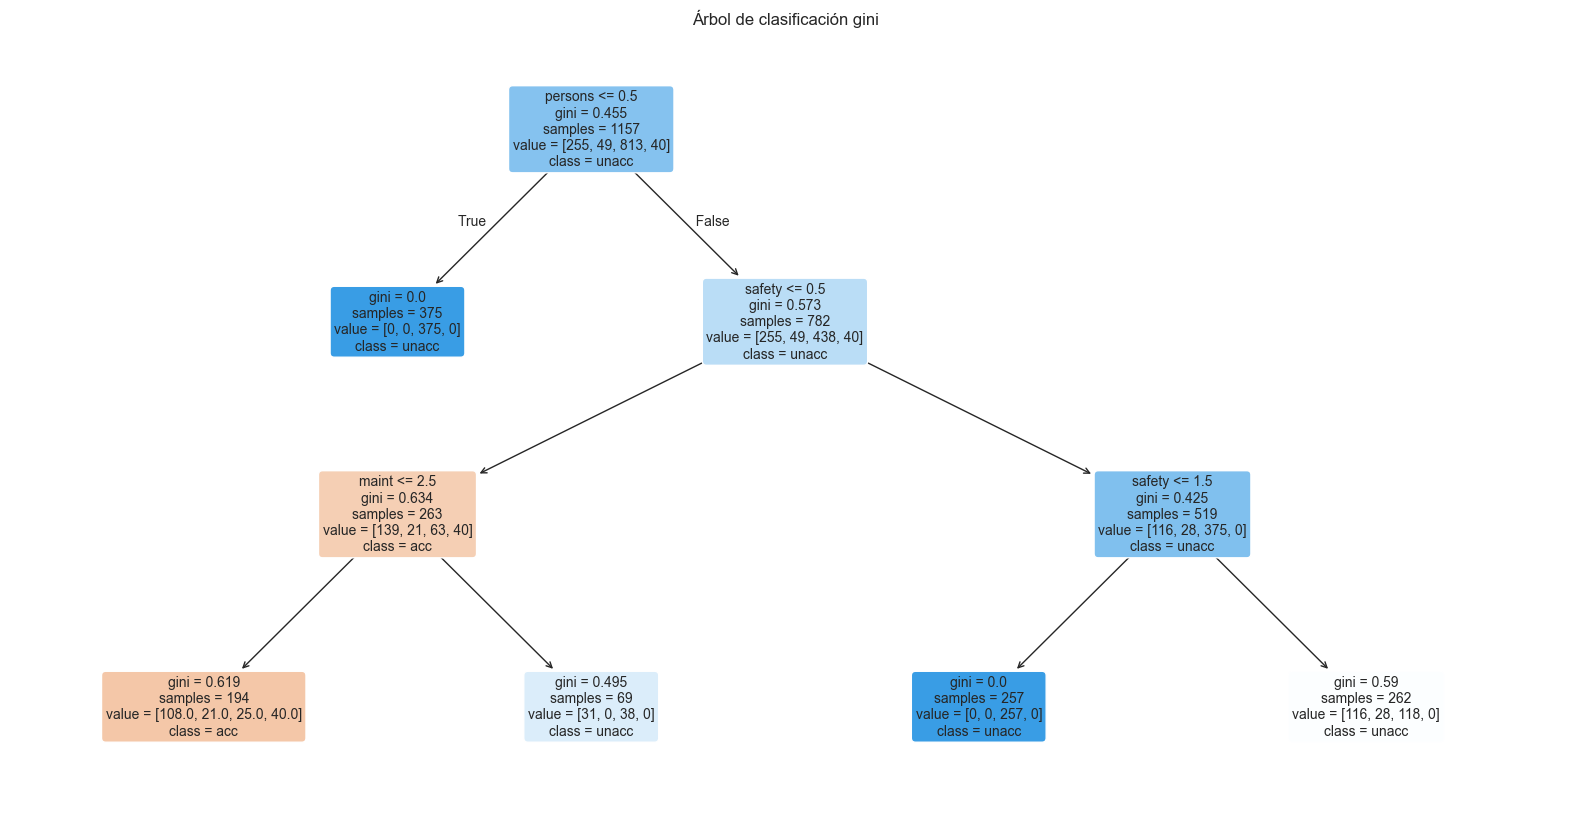

In [53]:
# TODO: Visualizar el árbol de decisión con Gini
#
# Instrucciones:
# 1. Cree una figura grande: plt.figure(figsize=(20, 10))
# 2. Use plot_tree() con los siguientes parámetros:
#    - clf_gini (el modelo)
#    - feature_names=list(X.columns)
#    - class_names=list(class_names)
#    - filled=True
#    - rounded=True
#    - fontsize=10
# 3. Agregue título
plt.figure(figsize=(20, 10))
plot_tree(decision_tree= clf_gini, feature_names=list(X.columns), class_names=list(nombres_clases), filled=True, rounded=True, fontsize=10)
plt.title("Árbol de clasificación gini")


In [54]:
# TODO: Mostrar la importancia de las características
#
# Instrucciones:
# 1. Cree un DataFrame con columnas 'Feature' y 'Importance'
#    - 'Feature': X.columns
#    - 'Importance': clf_gini.feature_importances_
# 2. Ordene por importancia descendente con sort_values()
# 3. Visualice con sns.barplot()
# 4. Imprima la tabla de importancias

gini_inportancia_dic = {
    'Feature': X.columns,
    'Importance': clf_gini.feature_importances_
}

df_gini_inportancia = pd.DataFrame(data= gini_inportancia_dic)
df_gini_inportancia = df_gini_inportancia.sort_values(by= 'Importance', ascending=False)
df_gini_inportancia

,Feature,Importance
5,safety,0.585506
3,persons,0.357400
1,maint,0.057095
0,buying,0.000000
2,doors,0.000000
4,lug_boot,0.000000


<Axes: xlabel='Feature', ylabel='Importance'>

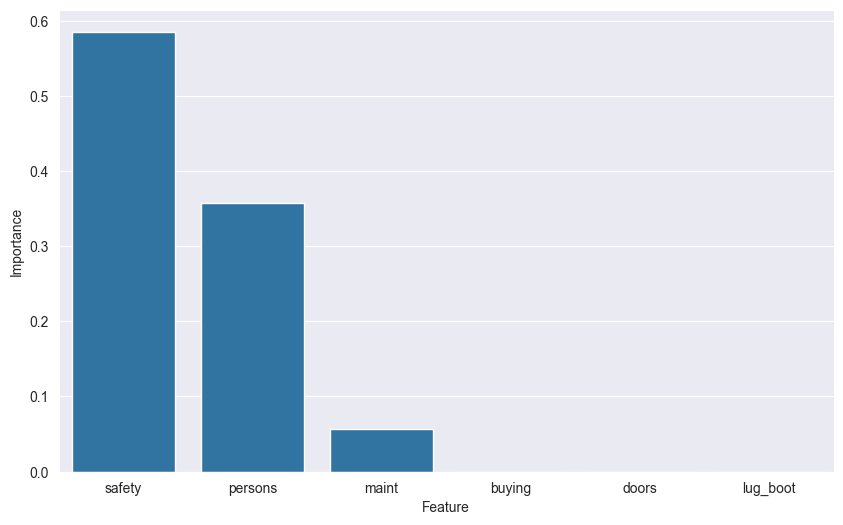

In [55]:
sns.barplot(data = df_gini_inportancia, y= "Importance", x="Feature" )

### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [56]:
# TODO: Experimentar con diferentes valores de max_depth
#
# Instrucciones:
# 1. Defina depths = [1, 2, 3, 5, 7, 10, None] (None = sin límite)
# 2. Cree una lista vacía para resultados
# 3. Para cada depth:
#    a. Cree y entrene un DecisionTreeClassifier con ese max_depth
#    b. Calcule precisión en train y test
#    c. Guarde los resultados en un diccionario
# 4. Convierta a DataFrame e imprima

depths = [1, 2, 3, 5, 7, 10, None]
resultados_train = []
resultados_test = []
for profundidad in depths:
    arbol_clasificacion = DecisionTreeClassifier(max_depth= profundidad, random_state= 42)
    arbol_clasificacion.fit(X= X_train, y= y_train)
    y_pred_test= arbol_clasificacion.predict(X= X_test)
    y_pred_train= arbol_clasificacion.predict(X= X_train)
    exactitud_test = accuracy_score(y_pred= y_pred_test, y_true= y_test)
    exactitud_train = accuracy_score(y_pred= y_pred_train, y_true= y_train)
    resultados_train.append(exactitud_train)
    resultados_test.append(exactitud_test)

resultados_profundidades_dic = {
    "resultados_train": resultados_train,
    "resultados_test": resultados_test
}

df_resultados_profundidades = pd.DataFrame(data= resultados_profundidades_dic, index=depths)
df_resultados_profundidades


,resultados_train,resultados_test
1.0,0.702679,0.695271
2.0,0.768366,0.770578
3.0,0.774417,0.765324
5.0,0.855661,0.865149
7.0,0.929991,0.935201
10.0,0.993086,0.961471
NaN,1.000000,0.966725


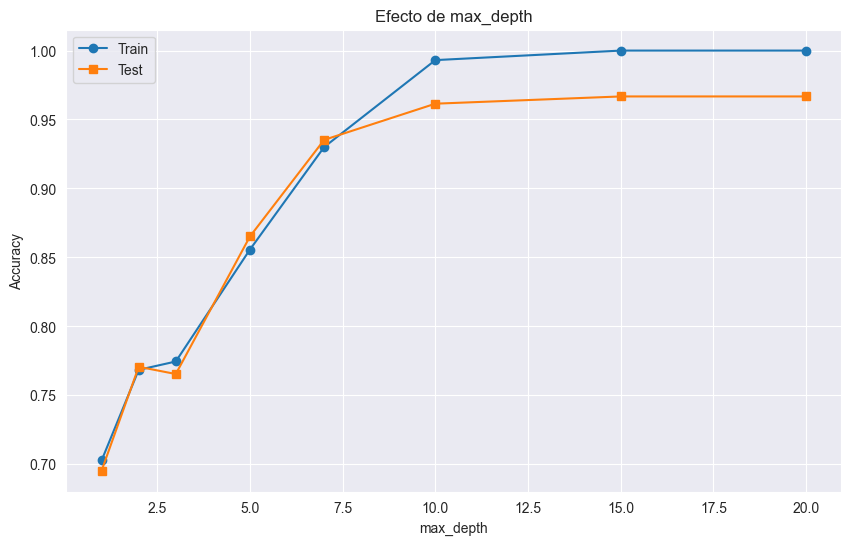

In [57]:
# TODO: Visualizar el efecto de max_depth
#
# Instrucciones:
# 1. Defina depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
# 2. Cree listas para train_scores y test_scores
# 3. Para cada depth, entrene un modelo y guarde las precisiones
# 4. Grafique ambas curvas (train y test) vs max_depth
# 5. Agregue leyenda, título y etiquetas
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
resultados_train = []
resultados_test = []
for profundidad in depths_plot:
    arbol_clasificacion = DecisionTreeClassifier(max_depth= profundidad, random_state= 42)
    arbol_clasificacion.fit(X= X_train, y= y_train)
    y_pred_test= arbol_clasificacion.predict(X= X_test)
    y_pred_train= arbol_clasificacion.predict(X= X_train)
    exactitud_test = accuracy_score(y_pred= y_pred_test, y_true= y_test)
    exactitud_train = accuracy_score(y_pred= y_pred_train, y_true= y_train)
    resultados_train.append(exactitud_train)
    resultados_test.append(exactitud_test)


plt.plot(depths_plot, resultados_train,marker='o', label='Train' )
plt.plot(depths_plot, resultados_test,marker='s', label='Test' )
plt.title('Efecto de max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()

### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C

In [58]:
# TODO: Experimentar con min_samples_split
#
# Instrucciones:
# 1. Defina min_samples_list = [2, 5, 10, 20, 50]
# 2. Para cada valor, entrene un modelo SIN limitar max_depth
# 3. Guarde precisión train, test, profundidad y hojas
# 4. Imprima los resultados en una tabla

min_samples_list = [2, 5, 10, 20, 50]
resultados_train = []
resultados_test = []
profundidad = []
hojas = []
for min_sample in min_samples_list:
    arbol_clasificacion = DecisionTreeClassifier(random_state= 42,min_samples_split= min_sample)
    arbol_clasificacion.fit(X= X_train, y= y_train)
    y_pred_test= arbol_clasificacion.predict(X= X_test)
    y_pred_train= arbol_clasificacion.predict(X= X_train)
    exactitud_test = accuracy_score(y_pred= y_pred_test, y_true= y_test)
    exactitud_train = accuracy_score(y_pred= y_pred_train, y_true= y_train)
    resultados_train.append(exactitud_train)
    resultados_test.append(exactitud_test)
    profundidad.append(arbol_clasificacion.get_depth())
    hojas.append(arbol_clasificacion.get_n_leaves())

resultados_profundidades_dic_2 = {
    "resultados_train": resultados_train,
    "resultados_test": resultados_test,
    "profundidad": profundidad,
    "Hojas" : hojas
}

df_resultados_profundidades_2 = pd.DataFrame(data=resultados_profundidades_dic_2, index= min_samples_list)
df_resultados_profundidades_2

,resultados_train,resultados_test,profundidad,Hojas
2,1.000000,0.966725,14,73
5,0.991357,0.956217,12,62
10,0.976664,0.942207,11,49
20,0.953328,0.931699,10,38
50,0.891098,0.886165,8,19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B

## Parte 11: Modelo Final Optimizado

In [59]:
# TODO: Entrenar modelo final con los mejores hiperparámetros
#
# Instrucciones:
# 1. Basado en sus experimentos, elija los mejores hiperparámetros
#    (sugerencia: criterion='gini', max_depth=7, min_samples_split=5)
# 2. Cree y entrene el modelo final
# 3. Calcule y muestre la precisión en test y train
# 4. Muestre profundidad y número de hojas

modelo_final = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=5)
modelo_final.fit(X= X_train, y= y_train )
y_pred_test_final = modelo_final.predict(X= X_test)
y_pred_train_final = modelo_final.predict(X= X_train)
exactitud_test_final = accuracy_score(y_pred=y_pred_test_final, y_true= y_test)
exactitud_train_final = accuracy_score(y_pred=y_pred_train_final, y_true= y_train)
profundidad_final = modelo_final.get_depth()
num_hojas_final = modelo_final.get_n_leaves()
print(f"exactitud_test_final: {exactitud_test_final}")
print(f"exactitud_train_final: {exactitud_train_final}")
print(f"profundidad_final: {profundidad_final}")
print(f"num_hojas_final: {num_hojas_final}")

exactitud_test_final: 0.9334500875656743
exactitud_train_final: 0.9282627484874676
profundidad_final: 7
num_hojas_final: 27


In [60]:
precision = precision_score(y_pred=y_pred_test_final, y_true= y_test,   average=None,  labels=[0])
precision

array([0.81756757])

In [61]:
label_encoders["class"].classes_[0]

'acc'

In [62]:
# TODO: Imprimir reporte de clasificación final
#
# Instrucciones:
# 1. Use classification_report() con las predicciones del modelo final
reporte_clasificacion_final = classification_report(y_pred=y_pred_test_final, y_true= y_test, target_names=label_encoders["class"].classes_)
print(reporte_clasificacion_final)

              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C